In [19]:
import requests
import pandas as pd
from datetime import datetime, timezone
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import get_cmap
from matplotlib.patches import Patch
import ast
import folium
from folium.plugins import MarkerCluster
import reverse_geocoder as rg
import re
import pycountry
import os
import numpy as np
import geopandas as gpd
import fiona
import sys
from shapely.geometry import Point
from sklearn.cluster import DBSCAN
import ruptures as rpt
from haversine import haversine
import functions as own
from timezonefinder import TimezoneFinder
import zoneinfo

Countries and
1) the number of users that made the majority of their observations in them
2) the number of users that made their first observation in them

In [4]:
df = pd.read_csv("../CWData_clean7.csv")
df["created_at_local"] = pd.to_datetime(df["created_at_local"])
df["year_month"] = pd.to_datetime(df["year_month"]).dt.to_period("M")

top_country = (
    df
    .groupby("top_country")
    .agg(
        number_of_users_top_country = ("created_by","nunique")
    )
    .reset_index()
)

first_country = (
    df
    .groupby("first_country")
    .agg(
        number_of_users_first_country = ("created_by","nunique")
    )
    .reset_index()
)

top_first_country = top_country.merge(first_country, how="outer", left_on="top_country", right_on="first_country")
top_first_country["Country"] = top_first_country["top_country"].fillna(top_first_country["first_country"])
top_first_country = top_first_country.drop(["top_country", "first_country"], axis=1)
top_first_country = top_first_country.fillna(0)
top_first_country = top_first_country[["Country", "number_of_users_top_country", "number_of_users_first_country"]]

pd.set_option("display.max_rows", None)
top_first_country

C:\Users\yanni\AppData\Local\Temp\ipykernel_28496\2850915188.py:1: DtypeWarning: Columns (0: Plastic_Amount, 1: Plastic_Location, 2: Plastic_RiverWidth, 3: Plastic_PET, 4: Plastic_POSoft, 5: Plastic_POHard, 6: Plastic_PS, 7: Plastic_PSE, 8: Plastic_PMultilayer, 9: Plastic_POther, 10: Plastic_Shore_Plotsize, 11: Plastic_Removed, 12: Plastic_River_Stagnant, 13: Waterlevel_Physical_Unit, 14: Streamtype, 15: Swimming_Quality, 16: Drinking_Quality, 17: Naturality, 18: StreamColor, 19: Stream_Ground_Visibility, 20: Stream_Animals, 21: Stream_Pollution_Reason, 22: Stream_sometimes_dry, 23: Stream_Name, 24: TempStream_snow_ice, 25: Stream_Waterquality, 26: Stream_Waterclarity, 27: StreamColor_other, 28: Stream_Vegetation, 29: Stream_Foam, 30: Stream_Algae, 31: Stream_Odor, 32: Stream_Odor_Type, 33: Stream_Odor_Type_other, 34: Stream_Litter, 35: Stream_Flow_Alteration, 36: Stream_typical_Color, 37: Stream_Drainage_Basin, 38: Lake_Usage, 39: Lake_Usage_Nr, 40: Lake_Access, 41: Lake_Shore_State, 

,Country,number_of_users_top_country,number_of_users_first_country
0,Afghanistan,1.0,1.0
1,Albania,1.0,1.0
2,Argentina,7.0,7.0
3,Australia,11.0,10.0
4,Austria,66.0,65.0
5,Bangladesh,2.0,2.0
6,Belgium,2.0,2.0
7,Brazil,43.0,43.0
8,Bulgaria,2.0,2.0
9,Cambodia,1.0,1.0


Now, we want to know whether countries actually experienced real adoption of the CrowdWater app. For this, we look whether, in each country, there was/were (a) time period(s) of at least 3 months with at least 10 observations per month.

In [5]:
def sustained_adoption(df, min_obs=10, min_months=3):
    
    # 1. monthly aggregation
    df["year_month"] = pd.to_datetime(df["year_month"]).dt.to_period("M")
    
    monthly = (
        df.groupby(["Country", "year_month"])
          .size()
          .reset_index(name="monthly_obs")
    )
    
    results = []
    
    # 2. analyse per country
    for country, d in monthly.groupby("Country"):
        
        d = d.sort_values("year_month").copy()
        
        # add missing months
        full_index = pd.period_range(
            d["year_month"].min(),
            d["year_month"].max(),
            freq="M"
        )
        
        d = (
            d.set_index("year_month")["monthly_obs"]
             .reindex(full_index, fill_value=0)
             .to_frame()
        )
        d.index.name = "year_month"
        d = d.reset_index()
        
        # 3. test threshold
        d["above_threshold"] = d["monthly_obs"] >= min_obs
        
        # 4. identify consecutive phases
        d["group"] = (d["above_threshold"] != d["above_threshold"].shift()).cumsum()
        
        runs = (
            d[d["above_threshold"]]
            .groupby("group")
            .agg(
                start=("year_month", "min"),
                end=("year_month", "max"),
                length=("year_month", "count")
            )
            .reset_index(drop=True)
        )
        
        # 5. only keep phases with more than x months duration
        runs = runs[runs["length"] >= min_months]
        
        # 6. save results
        for _, row in runs.iterrows():
            results.append({
                "Country": country,
                "Start_Month": row["start"].to_timestamp(),
                "End_Month": row["end"].to_timestamp(),
                "Duration_Months": row["length"]
            })
    
    return pd.DataFrame(results)

In [6]:
df = pd.read_csv("../CWData_clean7.csv")
df["date"] = pd.to_datetime(df["date"])

sustained_phases = sustained_adoption(df)
sustained_phases

C:\Users\yanni\AppData\Local\Temp\ipykernel_28496\2525058573.py:1: DtypeWarning: Columns (0: Plastic_Amount, 1: Plastic_Location, 2: Plastic_RiverWidth, 3: Plastic_PET, 4: Plastic_POSoft, 5: Plastic_POHard, 6: Plastic_PS, 7: Plastic_PSE, 8: Plastic_PMultilayer, 9: Plastic_POther, 10: Plastic_Shore_Plotsize, 11: Plastic_Removed, 12: Plastic_River_Stagnant, 13: Waterlevel_Physical_Unit, 14: Streamtype, 15: Swimming_Quality, 16: Drinking_Quality, 17: Naturality, 18: StreamColor, 19: Stream_Ground_Visibility, 20: Stream_Animals, 21: Stream_Pollution_Reason, 22: Stream_sometimes_dry, 23: Stream_Name, 24: TempStream_snow_ice, 25: Stream_Waterquality, 26: Stream_Waterclarity, 27: StreamColor_other, 28: Stream_Vegetation, 29: Stream_Foam, 30: Stream_Algae, 31: Stream_Odor, 32: Stream_Odor_Type, 33: Stream_Odor_Type_other, 34: Stream_Litter, 35: Stream_Flow_Alteration, 36: Stream_typical_Color, 37: Stream_Drainage_Basin, 38: Lake_Usage, 39: Lake_Usage_Nr, 40: Lake_Access, 41: Lake_Shore_State, 

,Country,Start_Month,End_Month,Duration_Months
0,Australia,2021-06-01,2021-12-01,7
1,Austria,2018-01-01,2025-08-01,92
2,Austria,2025-10-01,2025-12-01,3
3,Canada,2019-04-01,2024-05-01,62
4,Chile,2020-04-01,2022-10-01,31
5,Costa Rica,2023-03-01,2023-05-01,3
6,Costa Rica,2024-02-01,2024-05-01,4
7,Cyprus,2019-04-01,2019-09-01,6
8,Cyprus,2020-03-01,2020-06-01,4
9,Estonia,2022-06-01,2022-11-01,6


We also need the monthly observation totals for each country

In [8]:
df = pd.read_csv("../CWData_clean7.csv")

df["year_month"] = pd.to_datetime(df["year_month"]).dt.to_period("M")

monthly_total_obs_per_country = (
    df.groupby(["Country", "year_month"])
      .size()
      .reset_index(name="monthly_obs")
)

monthly_total_obs_per_country.head()

C:\Users\yanni\AppData\Local\Temp\ipykernel_28496\805408118.py:1: DtypeWarning: Columns (0: Plastic_Amount, 1: Plastic_Location, 2: Plastic_RiverWidth, 3: Plastic_PET, 4: Plastic_POSoft, 5: Plastic_POHard, 6: Plastic_PS, 7: Plastic_PSE, 8: Plastic_PMultilayer, 9: Plastic_POther, 10: Plastic_Shore_Plotsize, 11: Plastic_Removed, 12: Plastic_River_Stagnant, 13: Waterlevel_Physical_Unit, 14: Streamtype, 15: Swimming_Quality, 16: Drinking_Quality, 17: Naturality, 18: StreamColor, 19: Stream_Ground_Visibility, 20: Stream_Animals, 21: Stream_Pollution_Reason, 22: Stream_sometimes_dry, 23: Stream_Name, 24: TempStream_snow_ice, 25: Stream_Waterquality, 26: Stream_Waterclarity, 27: StreamColor_other, 28: Stream_Vegetation, 29: Stream_Foam, 30: Stream_Algae, 31: Stream_Odor, 32: Stream_Odor_Type, 33: Stream_Odor_Type_other, 34: Stream_Litter, 35: Stream_Flow_Alteration, 36: Stream_typical_Color, 37: Stream_Drainage_Basin, 38: Lake_Usage, 39: Lake_Usage_Nr, 40: Lake_Access, 41: Lake_Shore_State, 4

,Country,year_month,monthly_obs
0,Afghanistan,2017-07,1
1,Albania,2019-10,1
2,Argentina,2018-01,6
3,Argentina,2019-06,1
4,Argentina,2020-11,7


First and total number of observations and total number of users per country; same as in Part 1

In [9]:
df = pd.read_csv("../CWData_clean7.csv")
df["created_at_local"] = pd.to_datetime(df["created_at_local"])
df["year_month"] = pd.to_datetime(df["year_month"]).dt.to_period("M")

first_countries = (
    df
    .groupby("Country")
    .agg(
        first_date = ("created_at_local","min"),
        total_observations = ("created_at_local","count"),
        unique_users = ("created_by","nunique")
    )
    .reset_index()
)

pd.set_option("display.max_rows", None)

first_countries

C:\Users\yanni\AppData\Local\Temp\ipykernel_28496\1242181566.py:1: DtypeWarning: Columns (0: Plastic_Amount, 1: Plastic_Location, 2: Plastic_RiverWidth, 3: Plastic_PET, 4: Plastic_POSoft, 5: Plastic_POHard, 6: Plastic_PS, 7: Plastic_PSE, 8: Plastic_PMultilayer, 9: Plastic_POther, 10: Plastic_Shore_Plotsize, 11: Plastic_Removed, 12: Plastic_River_Stagnant, 13: Waterlevel_Physical_Unit, 14: Streamtype, 15: Swimming_Quality, 16: Drinking_Quality, 17: Naturality, 18: StreamColor, 19: Stream_Ground_Visibility, 20: Stream_Animals, 21: Stream_Pollution_Reason, 22: Stream_sometimes_dry, 23: Stream_Name, 24: TempStream_snow_ice, 25: Stream_Waterquality, 26: Stream_Waterclarity, 27: StreamColor_other, 28: Stream_Vegetation, 29: Stream_Foam, 30: Stream_Algae, 31: Stream_Odor, 32: Stream_Odor_Type, 33: Stream_Odor_Type_other, 34: Stream_Litter, 35: Stream_Flow_Alteration, 36: Stream_typical_Color, 37: Stream_Drainage_Basin, 38: Lake_Usage, 39: Lake_Usage_Nr, 40: Lake_Access, 41: Lake_Shore_State, 

,Country,first_date,total_observations,unique_users
0,Afghanistan,2017-07-03 12:47:55,1,1
1,Albania,2019-10-17 13:44:38,1,1
2,Argentina,2018-01-13 10:41:01,64,9
3,Australia,2017-12-12 17:38:56,357,14
4,Austria,2017-03-04 14:28:56,6094,95
5,Bangladesh,2023-05-25 13:25:55,4,2
6,Belgium,2017-08-03 21:09:49,12,7
7,Brazil,2020-09-04 13:40:09,139,45
8,Bulgaria,2019-08-13 15:47:52,25,3
9,Cambodia,2022-02-26 11:52:59,4,2


We combine the dataset with the sustained adoption phases, the dataset with the countries' first observation date, total observations, total users and the dataset with the number of observations in each month (in order to calculate the average monthly observation counts in a phase).

In [10]:
# uses first_countries and sustained_phases

first_sustained_combo = pd.merge(first_countries, sustained_phases, how="right")
first_sustained_combo["first_date"] = pd.to_datetime(first_sustained_combo["first_date"])
first_sustained_combo["Start_Month"] = pd.to_datetime(first_sustained_combo["Start_Month"])
first_sustained_combo["End_Month"] = pd.to_datetime(first_sustained_combo["End_Month"])

first_sustained_combo = first_sustained_combo.sort_values(["Country", "Start_Month"])

first_sustained_combo["phase_number"] = (first_sustained_combo.groupby("Country").cumcount() + 1)

first_period = first_sustained_combo["first_date"].dt.to_period("M")
start_period = first_sustained_combo["Start_Month"].dt.to_period("M")
end_period = first_sustained_combo["End_Month"].dt.to_period("M")

prev_end_p = (first_sustained_combo.groupby("Country")["End_Month"].shift(1).dt.to_period("M"))

first_sustained_combo["months_since_previous"] = pd.NA

# first phase: time since very first observation in the country
mask_first = first_sustained_combo["phase_number"] == 1
first_sustained_combo.loc[mask_first, "months_since_previous"] = (
    start_period[mask_first] - first_period[mask_first]
).apply(lambda x: x.n)

# second and later phases: time since end of previous phase
mask_later = first_sustained_combo["phase_number"] > 1
first_sustained_combo.loc[mask_later, "months_since_previous"] = (
    start_period[mask_later] - prev_end_p[mask_later]
).apply(lambda x: x.n)

# compute average number of observations during each phase
avg_values = []

for idx, row in first_sustained_combo.iterrows():
    
    country = row["Country"]
    start = row["Start_Month"].to_period("M")
    end = row["End_Month"].to_period("M")
    
    # filter relevant months
    subset = monthly_total_obs_per_country[
        (monthly_total_obs_per_country["Country"] == country) &
        (monthly_total_obs_per_country["year_month"] >= start) &
        (monthly_total_obs_per_country["year_month"] <= end)
    ]
    
    total_obs = subset["monthly_obs"].sum()
    duration = row["Duration_Months"]
    
    avg_monthly = total_obs / duration if duration > 0 else 0
    
    avg_values.append(round(avg_monthly,2))

first_sustained_combo["avg_monthly_observations"] = avg_values

first_sustained_combo

,Country,first_date,total_observations,unique_users,Start_Month,End_Month,Duration_Months,phase_number,months_since_previous,avg_monthly_observations
0,Australia,2017-12-12 17:38:56,357,14,2021-06-01,2021-12-01,7,1,42,35.29
1,Austria,2017-03-04 14:28:56,6094,95,2018-01-01,2025-08-01,92,1,10,65.23
2,Austria,2017-03-04 14:28:56,6094,95,2025-10-01,2025-12-01,3,2,2,23.33
3,Canada,2017-05-06 14:48:03,2165,46,2019-04-01,2024-05-01,62,1,23,33.98
4,Chile,2018-01-07 18:37:19,943,46,2020-04-01,2022-10-01,31,1,27,29.00
5,Costa Rica,2018-07-17 08:24:14,596,163,2023-03-01,2023-05-01,3,1,56,91.67
6,Costa Rica,2018-07-17 08:24:14,596,163,2024-02-01,2024-05-01,4,2,9,26.75
7,Cyprus,2019-03-19 07:14:30,536,4,2019-04-01,2019-09-01,6,1,1,33.67
8,Cyprus,2019-03-19 07:14:30,536,4,2020-03-01,2020-06-01,4,2,6,22.75
9,Estonia,2017-08-10 17:40:41,1531,6,2022-06-01,2022-11-01,6,1,58,50.33


I now have multiple dataframes with important information about countries and their adoption of the CrowdWater app.

first_sustained_combo: first observation in a country and all phases of sustained adoption in the same country (>= 10 obs/month for at least 3 months) and the time between phases

first_countries: the total number of observations and number of unique users in each country

first_country: the number of users that have each country as their first country (i.e. made their first observation in the country)

top_country: the number of users that have each country as their top country (i.e. made the majority of their observation in the country)

Time-to-Adoption map

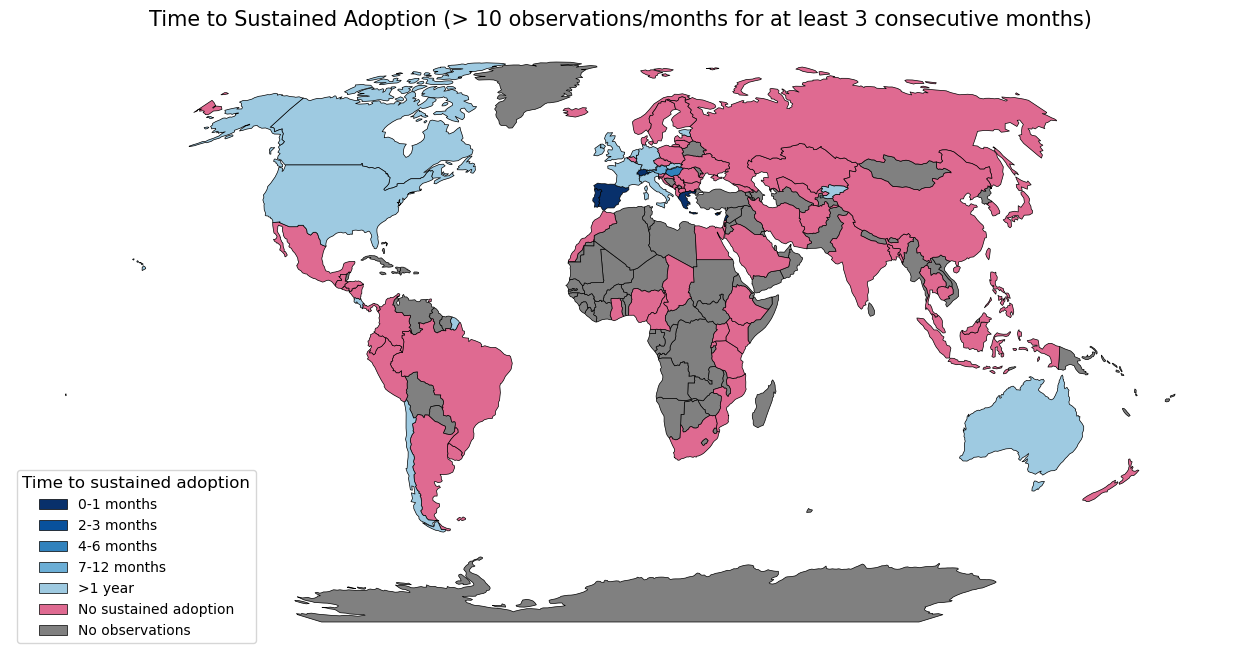

In [11]:
# uses first_sustained_combo and first_countries

first_sustained_combo_merged = first_sustained_combo.merge(first_countries, on="Country", how="right")

first_phase = first_sustained_combo_merged[
    (first_sustained_combo_merged["phase_number"] == 1) | 
    (first_sustained_combo_merged["phase_number"].isna())
]

first_phase["ISO_A3"] = first_phase["Country"].apply(own.get_iso3)

first_phase["time_to_adoption_months"] = ((first_phase["Start_Month"] - first_phase["first_date_x"]) / pd.Timedelta(days=30))

world = gpd.read_file(f"../ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp", engine="fiona")

map_df = world.merge(first_phase, left_on="ADM0_A3", right_on="ISO_A3", how="left").to_crs("+proj=robin")

conditions = [
    map_df["time_to_adoption_months"].notna(),                 # sustained adoption
    map_df["total_observations_y"].notna(),                    # observations but no adoption
]

choices = [
    "adoption",
    "observations_only"
]

map_df["status"] = np.select(conditions, choices, default="no_observations")

map_df["adoption_class"] = pd.cut(
    map_df["time_to_adoption_months"],
    bins=[-1,1,3,6,12,1000],
    labels=[
        "0-1 months",
        "2-3 months",
        "4-6 months",
        "7-12 months",
        ">1 year"
    ]
)

# colors for adoption classes
blues = plt.cm.Blues_r
adoption_colors = {
    "0-1 months": "#08306b",
    "2-3 months": "#08519c",
    "4-6 months": "#3182bd",
    "7-12 months": "#6baed6",
    ">1 year": "#9ecae1",
}

fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# no observations
map_df[map_df["status"] == "no_observations"].plot(
    ax=ax, color="grey", edgecolor="black", linewidth=0.5
)

# observations but no adoption
map_df[map_df["status"] == "observations_only"].plot(
    ax=ax, color="#df6a91", edgecolor="black", linewidth=0.5
)

# adoption
for label, color in adoption_colors.items():
    subset = map_df[
        (map_df["status"] == "adoption") & 
        (map_df["adoption_class"] == label)
    ]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor="black", linewidth=0.5)

# manual legend
legend_handles = [
    mpatches.Patch(facecolor=color, edgecolor="black", linewidth=0.5, label=label)
    for label, color in adoption_colors.items()
] + [
    mpatches.Patch(facecolor="#df6a91", edgecolor="black", linewidth=0.5, label="No sustained adoption"),
    mpatches.Patch(facecolor="grey", edgecolor="black", linewidth=0.5, label="No observations"),
]

ax.legend(handles=legend_handles, loc="lower left", title="Time to sustained adoption", title_fontsize=12)
ax.axis("off")
plt.title("Time to Sustained Adoption (> 10 observations/months for at least 3 consecutive months)", fontsize=15)
plt.savefig("../Products/Time_to_Sustained_Adoption.png", dpi=300, bbox_inches="tight")

Adoption Intensity Map (of first phase)

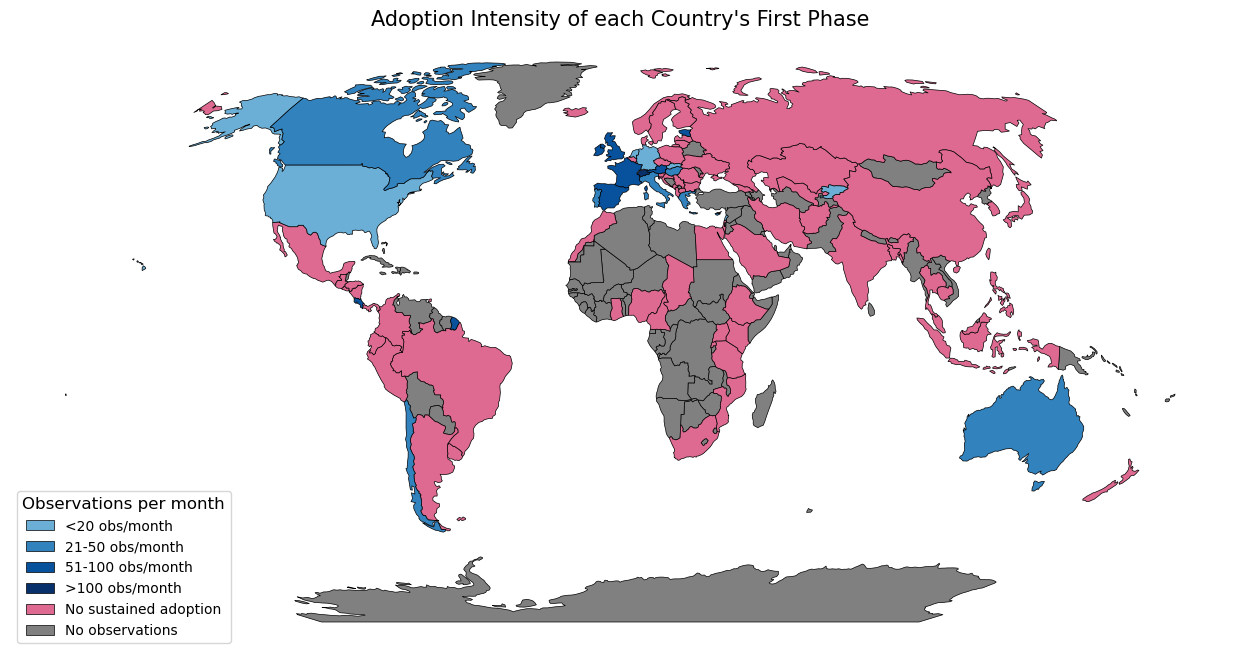

In [12]:
# uses first_sustained_combo and first_countries

first_sustained_combo_merged = first_sustained_combo.merge(first_countries, on="Country", how="right")

first_phase = first_sustained_combo_merged[
    (first_sustained_combo_merged["phase_number"] == 1) | 
    (first_sustained_combo_merged["phase_number"].isna())
]

first_phase["ISO_A3"] = first_phase["Country"].apply(own.get_iso3)

world = gpd.read_file(f"../ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp", engine="fiona")

map_df = world.merge(first_phase, left_on="ADM0_A3", right_on="ISO_A3", how="left").to_crs("+proj=robin")

conditions = [
    map_df["avg_monthly_observations"].notna(),                 # sustained adoption
    map_df["total_observations_y"].notna(),                    # observations but no adoption
]

choices = [
    "adoption",
    "observations_only"
]

map_df["status"] = np.select(conditions, choices, default="no_observations")

map_df["monthly_obs_class"] = pd.cut(
    map_df["avg_monthly_observations"],
    bins=[0,20,50,100,10000],
    labels=[
        "<20 obs/month",
        "21-50 obs/month",
        "51-100 obs/month",
        ">100 obs/month",
    ]
)

# define colors
blues = plt.cm.Blues_r
adoption_colors = {
    "<20 obs/month": "#6baed6",
    "21-50 obs/month": "#3182bd",
    "51-100 obs/month": "#08519c",
    ">100 obs/month": "#08306b"
    #">1 year": "#9ecae1",
}

fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# no observations
map_df[map_df["status"] == "no_observations"].plot(
    ax=ax, color="grey", edgecolor="black", linewidth=0.5
)

# observations but no adoption
map_df[map_df["status"] == "observations_only"].plot(
    ax=ax, color="#df6a91", edgecolor="black", linewidth=0.5
)

# adoption
for label, color in adoption_colors.items():
    subset = map_df[
        (map_df["status"] == "adoption") & 
        (map_df["monthly_obs_class"] == label)
    ]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor="black", linewidth=0.5)

# legend
legend_handles = [
    mpatches.Patch(facecolor=color, edgecolor="black", linewidth=0.5, label=label)
    for label, color in adoption_colors.items()
] + [
    mpatches.Patch(facecolor="#df6a91", edgecolor="black", linewidth=0.5, label="No sustained adoption"),
    mpatches.Patch(facecolor="grey", edgecolor="black", linewidth=0.5, label="No observations"),
]

ax.legend(handles=legend_handles, loc="lower left", title="Observations per month", title_fontsize=12)
ax.axis("off")
plt.title("Adoption Intensity of each Country's First Phase", fontsize=15)
plt.savefig("../Products/Adoption_Intensity_first_phase.png", dpi=300, bbox_inches="tight")

How long the first adoption phase lasts (only UK and Switzerland have ongoing first phases)

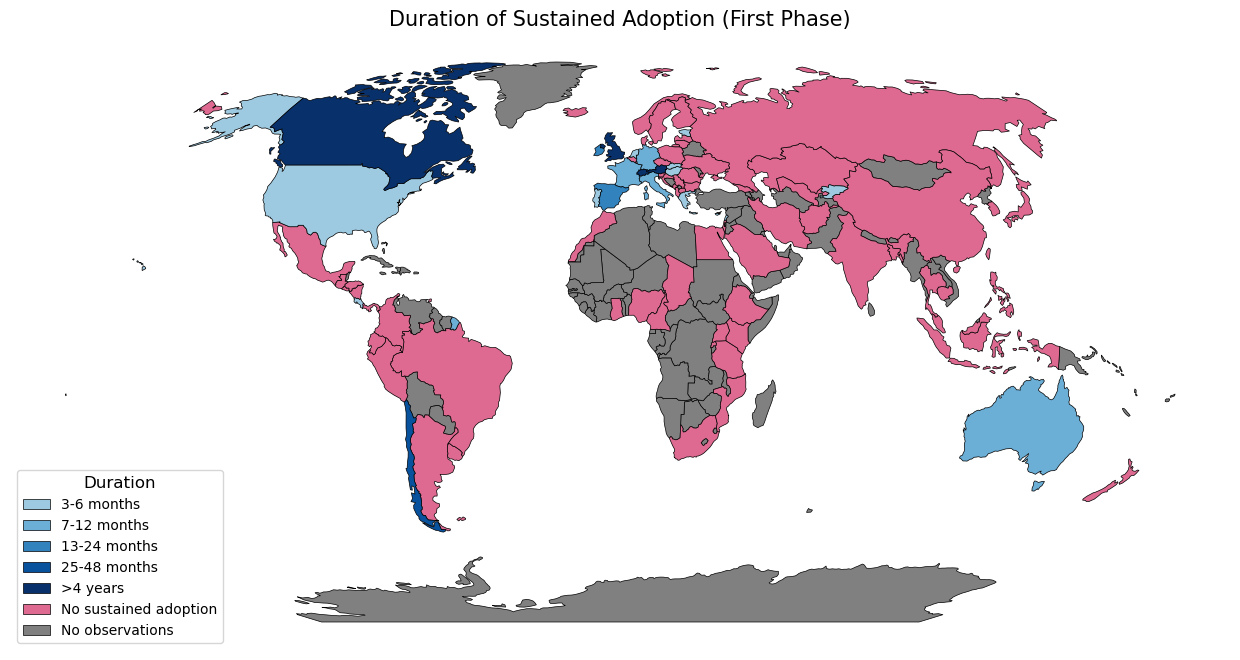

In [13]:
# uses first_sustained_combo and first_countries

first_sustained_combo_merged = first_sustained_combo.merge(first_countries, on="Country", how="right")

first_phase = first_sustained_combo_merged[
    (first_sustained_combo_merged["phase_number"] == 1) | 
    (first_sustained_combo_merged["phase_number"].isna())
]

first_phase["ISO_A3"] = first_phase["Country"].apply(own.get_iso3)

world = gpd.read_file(f"../ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp", engine="fiona")

map_df = world.merge(first_phase, left_on="ADM0_A3", right_on="ISO_A3", how="left").to_crs("+proj=robin")

conditions = [
    map_df["Duration_Months"].notna(),                 # sustained adoption
    map_df["total_observations_y"].notna(),            # observations but no adoption
]

choices = [
    "adoption",
    "observations_only"
]

map_df["status"] = np.select(conditions, choices, default="no_observations")

map_df["duration_class"] = pd.cut(
    map_df["Duration_Months"],
    bins=[0,6,12,24,48,1000],
    labels=[
        "3-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        ">4 years"
    ]
)

# define colors
blues = plt.cm.Blues_r
adoption_colors = {
    "3-6 months": "#9ecae1",
    "7-12 months": "#6baed6",
    "13-24 months": "#3182bd",
    "25-48 months": "#08519c",
    ">4 years": "#08306b"
}

fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# no observations
map_df[map_df["status"] == "no_observations"].plot(
    ax=ax, color="grey", edgecolor="black", linewidth=0.5
)

# observations but no adoption
map_df[map_df["status"] == "observations_only"].plot(
    ax=ax, color="#df6a91", edgecolor="black", linewidth=0.5
)

# adoption
for label, color in adoption_colors.items():
    subset = map_df[
        (map_df["status"] == "adoption") & 
        (map_df["duration_class"] == label)
    ]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor="black", linewidth=0.5)

# legend
legend_handles = [
    mpatches.Patch(facecolor=color, edgecolor="black", linewidth=0.5, label=label)
    for label, color in adoption_colors.items()
] + [
    mpatches.Patch(facecolor="#df6a91", edgecolor="black", linewidth=0.5, label="No sustained adoption"),
    mpatches.Patch(facecolor="grey", edgecolor="black", linewidth=0.5, label="No observations"),
]

ax.legend(handles=legend_handles, loc="lower left", title="Duration", title_fontsize=12)
ax.axis("off")
plt.title("Duration of Sustained Adoption (First Phase)", fontsize=15)
plt.savefig("../Products/Duration_of_Adoption.png", dpi=300, bbox_inches="tight")

Initial Adoption Wave Map (map the start of the first phase)

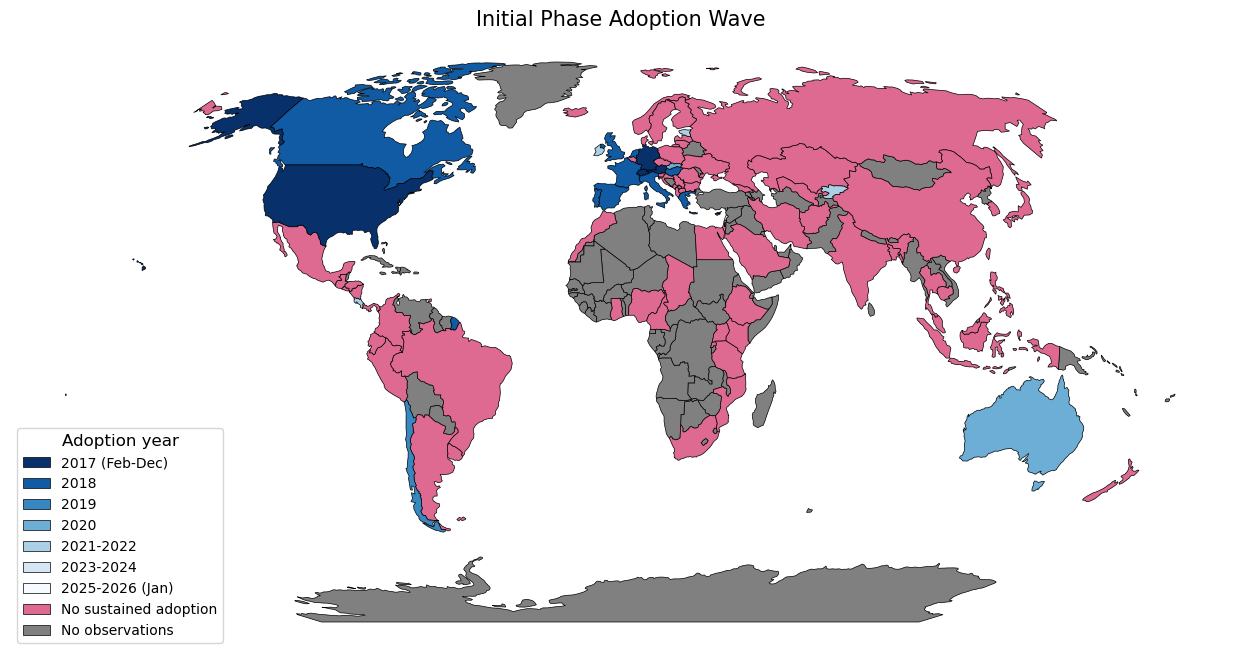

In [14]:
# uses first_sustained_combo and first_countries

first_sustained_combo_merged = first_sustained_combo.merge(first_countries, on="Country", how="right")

first_phase = first_sustained_combo_merged[
    (first_sustained_combo_merged["phase_number"] == 1) | 
    (first_sustained_combo_merged["phase_number"].isna())
]

first_phase["ISO_A3"] = first_phase["Country"].apply(own.get_iso3)

world = gpd.read_file(f"../ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp", engine="fiona")

map_df = world.merge(first_phase, left_on="ADM0_A3", right_on="ISO_A3", how="left").to_crs("+proj=robin")

map_df["Start_Month"] = map_df["Start_Month"].dt.year

conditions = [
    map_df["Start_Month"].notna(),                             # sustained adoption
    map_df["total_observations_y"].notna(),                    # observations but no adoption
]

choices = [
    "adoption",
    "observations_only"
]

map_df["status"] = np.select(conditions, choices, default="no_observations")

map_df["month_class"] = pd.cut(
    map_df["Start_Month"],
    bins=[2016,2018,2019,2020,2021,2023,2025,2027],
    labels=[
        "2017 (Feb-Dec)",
        "2018",
        "2019",
        "2020",
        "2021-2022",
        "2023-2024",
        "2025-2026 (Jan)"
    ]
)

fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# no observations
map_df[map_df["status"] == "no_observations"].plot(
    ax=ax, color="grey", edgecolor="black", linewidth=0.5
)

# observations but no adoption
map_df[map_df["status"] == "observations_only"].plot(
    ax=ax, color="#df6a91", edgecolor="black", linewidth=0.5
)

# adoption
map_df[map_df["status"]=="adoption"].plot(
    column="month_class",
    cmap="Blues_r",
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.5
)

# Legend
classes = map_df["month_class"].cat.categories
cmap = plt.cm.Blues_r
colors = [cmap(i/(len(classes)-1)) for i in range(len(classes))]

legend_handles = [
    mpatches.Patch(facecolor=colors[i], edgecolor="black", linewidth=0.5, label=classes[i])
    for i in range(len(classes))
] + [
    mpatches.Patch(facecolor="#df6a91", edgecolor="black", linewidth=0.5, label="No sustained adoption"),
    mpatches.Patch(facecolor="grey", edgecolor="black", linewidth=0.5, label="No observations"),
]

ax.legend(handles=legend_handles, loc="lower left", title="Adoption year", title_fontsize=12)
ax.axis("off")
plt.title("Initial Phase Adoption Wave", fontsize=15)
plt.savefig("../Products/Initial_Phase_Adoption_Wave.png", dpi=300, bbox_inches="tight")

Full Adoption Wave Map, all phases in all countries, monthly map series

In [15]:
# uses first_sustained_combo and first_countries

phases = first_sustained_combo.merge(first_countries, on="Country", how="right").copy()
world = gpd.read_file("../ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp", engine="fiona")

phases["ISO_A3"] = phases["Country"].apply(own.get_iso3)

start = phases["Start_Month"].min()
end = phases["End_Month"].max()
months = pd.date_range(start, end, freq="MS")

obs_only = phases[
    (phases["total_observations_y"].notna()) &
    (phases["phase_number"].isna())
]

obs_only_map = world.merge(
    obs_only,
    left_on="ADM0_A3",
    right_on="ISO_A3",
    how="inner"
).to_crs("+proj=robin")

adoption_map = world.merge(
    phases,
    left_on="ADM0_A3",
    right_on="ISO_A3",
    how="inner"
).to_crs("+proj=robin")

# phase color definition
max_phase = phases["phase_number"].max()
phase_colors = plt.cm.Blues_r(np.linspace(0.2, 1, int(max_phase)))  # von hell nach dunkel
phase_color_map = {i+1: phase_colors[i] for i in range(int(max_phase))}

# start of first phase per country
first_phase_start = phases.groupby("ISO_A3")["Start_Month"].min()
adoption_map["first_phase_start"] = adoption_map["ISO_A3_y"].map(first_phase_start)

for month in months:

    fig, ax = plt.subplots(1,1, figsize=(16,8))

    # basemap, including countries without any observations ever
    world.to_crs("+proj=robin").plot(
        ax=ax, color="grey", edgecolor="black", linewidth=0.3
    )

    # active countries
    active = adoption_map[
        (adoption_map["Start_Month"] <= month) &
        (adoption_map["End_Month"] >= month)
    ]

    # countries before their first phase
    before_first = adoption_map[
        (month < adoption_map["first_phase_start"])
    ]
    before_first = before_first[["ISO_A3_y"]].drop_duplicates()

    if not before_first.empty:
        before_first_map = world.merge(
            before_first,
            left_on="ADM0_A3",
            right_on="ISO_A3_y",
            how="inner"
        ).to_crs("+proj=robin")

        before_first_map.plot(
            ax=ax,
            color="lightgrey",
            edgecolor="black",
            linewidth=0.5
        )

    # countries between active phases
    all_adoption = adoption_map.copy()
    all_adoption = all_adoption[all_adoption["Start_Month"] <= month]

    between_phases = all_adoption[
        ~all_adoption["ISO_A3_y"].isin(active["ISO_A3_y"])
    ]
    between_phases = between_phases[["ISO_A3_y"]].drop_duplicates()

    if not between_phases.empty:
        between_phases_map = world.merge(
            between_phases,
            left_on="ADM0_A3",
            right_on="ISO_A3_y",
            how="inner"
        ).to_crs("+proj=robin")
        
        between_phases_map.plot(
            ax=ax, color="black",
            edgecolor="black",
            linewidth=0.5
        )

    # countries with observations but without sustained adoption ever
    obs_only_map.plot(
        ax=ax,
        color="#df6a91",
        edgecolor="black",
        linewidth=0.5
    )

    # which phase it is for countries
    for phase_num, color in phase_color_map.items():
        subset = active[active["phase_number"] == phase_num]
        if not subset.empty:
            subset.plot(
                ax=ax, 
                color=color, 
                edgecolor="black", 
                linewidth=0.5
            )

    ax.axis("off")
    plt.title(f"CrowdWater Adoption Wave - {month.strftime('%Y-%m')}", fontsize=15)

    # manual legend
    legend_handles = [
        mpatches.Patch(facecolor=color, edgecolor="black", linewidth=0.5, label=f"Active phase {phase_num}")
        for phase_num, color in phase_color_map.items()
    ] + [
        mpatches.Patch(facecolor="lightgrey", edgecolor="black", linewidth=0.5, label="Before first phase"),
                mpatches.Patch(facecolor="black", edgecolor="black", linewidth=0.5, label="Between/after phases"),
        mpatches.Patch(facecolor="#df6a91", edgecolor="black", linewidth=0.5, label="No sustained adoption"),
        mpatches.Patch(facecolor="grey", edgecolor="black", linewidth=0.5, label="No observations")
    ]

    ax.legend(handles=legend_handles, loc="lower left", title="Status / Phase", title_fontsize=12)
    
    # safe
    plt.savefig(
        f"../Products/Adoption_Wave_Maps/Adoption_{month.strftime('%Y_%m')}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

First local observation

local_adoption: when did locals of each country use CrowdWater for the first time (local = have the country as top country or as first country)?

In [16]:
df = pd.read_csv("../CWData_clean7.csv")
df["date"] = pd.to_datetime(df["date"])

# first observation in each country
first_obs = (
    df.groupby("Country")["date"]
    .min()
    .reset_index()
    .rename(columns={"date": "first_observation_date"})
)

# local observations (user majority country = observation country)
local_df = df[df["Country"] == df["top_country"]]

first_local_obs = (
    local_df.groupby("Country")["date"]
    .min()
    .reset_index()
    .rename(columns={"date": "first_local_observation_date (Majority)"})
)

# merge
local_adoption = pd.merge(
    first_obs,
    first_local_obs,
    on="Country",
    how="left"
)

local_adoption["time_between_first_and_local (Majority)"] = local_adoption["first_local_observation_date (Majority)"] - local_adoption["first_observation_date"]

obs_between = []

for _, row in local_adoption.iterrows():

    country = row["Country"]
    start = row["first_observation_date"]
    end = row["first_local_observation_date (Majority)"]

    # if there are no locals
    if pd.isna(end):
        obs_between.append("no locals")
        continue

    subset = df[
        (df["Country"] == country) &
        (df["date"] >= start) &
        (df["date"] < end)
    ]

    obs_between.append(len(subset))

local_adoption["obs_between_first_and_local (Majority)"] = obs_between


# local observations (user first country = observation country)
local_df2 = df[df["Country"] == df["first_country"]]

first_local_obs2 = (
    local_df2.groupby("Country")["date"]
    .min()
    .reset_index()
    .rename(columns={"date": "first_local_observation_date (First)"})
)

# merge
local_adoption = pd.merge(
    local_adoption,
    first_local_obs2,
    on="Country",
    how="left"
)

local_adoption["time_between_first_and_local (First)"] = local_adoption["first_local_observation_date (First)"] - local_adoption["first_observation_date"]

obs_between2 = []

for _, row in local_adoption.iterrows():

    country = row["Country"]
    start = row["first_observation_date"]
    end = row["first_local_observation_date (First)"]

    # if there are no locals
    if pd.isna(end):
        obs_between2.append("no locals")
        continue

    subset = df[
        (df["Country"] == country) &
        (df["date"] >= start) &
        (df["date"] < end)
    ]

    obs_between2.append(len(subset))

local_adoption["obs_between_first_and_local (First)"] = obs_between2

local_adoption

C:\Users\yanni\AppData\Local\Temp\ipykernel_28496\3529431937.py:1: DtypeWarning: Columns (0: Plastic_Amount, 1: Plastic_Location, 2: Plastic_RiverWidth, 3: Plastic_PET, 4: Plastic_POSoft, 5: Plastic_POHard, 6: Plastic_PS, 7: Plastic_PSE, 8: Plastic_PMultilayer, 9: Plastic_POther, 10: Plastic_Shore_Plotsize, 11: Plastic_Removed, 12: Plastic_River_Stagnant, 13: Waterlevel_Physical_Unit, 14: Streamtype, 15: Swimming_Quality, 16: Drinking_Quality, 17: Naturality, 18: StreamColor, 19: Stream_Ground_Visibility, 20: Stream_Animals, 21: Stream_Pollution_Reason, 22: Stream_sometimes_dry, 23: Stream_Name, 24: TempStream_snow_ice, 25: Stream_Waterquality, 26: Stream_Waterclarity, 27: StreamColor_other, 28: Stream_Vegetation, 29: Stream_Foam, 30: Stream_Algae, 31: Stream_Odor, 32: Stream_Odor_Type, 33: Stream_Odor_Type_other, 34: Stream_Litter, 35: Stream_Flow_Alteration, 36: Stream_typical_Color, 37: Stream_Drainage_Basin, 38: Lake_Usage, 39: Lake_Usage_Nr, 40: Lake_Access, 41: Lake_Shore_State, 

,Country,first_observation_date,first_local_observation_date (Majority),time_between_first_and_local (Majority),obs_between_first_and_local (Majority),first_local_observation_date (First),time_between_first_and_local (First),obs_between_first_and_local (First)
0,Afghanistan,2017-07-03,2017-07-03,0 days,0,2017-07-03,0 days,0
1,Albania,2019-10-17,2019-10-17,0 days,0,2019-10-17,0 days,0
2,Argentina,2018-01-13,2019-06-23,526 days,6,2019-06-23,526 days,6
3,Australia,2017-12-12,2017-12-12,0 days,0,2017-12-12,0 days,0
4,Austria,2017-03-04,2017-05-27,84 days,5,2017-05-27,84 days,5
5,Bangladesh,2023-05-25,2023-05-25,0 days,0,2023-05-25,0 days,0
6,Belgium,2017-08-03,2021-03-25,1330 days,3,2021-03-25,1330 days,3
7,Brazil,2020-09-04,2020-09-04,0 days,0,2020-09-04,0 days,0
8,Bulgaria,2019-08-13,2021-02-28,565 days,1,2021-02-28,565 days,1
9,Cambodia,2022-02-26,2026-01-14,1418 days,3,2026-01-14,1418 days,3


How long it takes for local users to adopt the app compared to travelers

In [17]:
def local_adoption_plotter(df, local_type="Majority", diff_type="time"):
    df = df.copy()
    col = f"{diff_type}_between_first_and_local ({local_type})"
    
    if local_type not in ["Majority","First"]:
        raise Exception('local_type expects "Majority" or "First"')
    if diff_type not in ["time","obs"]:
        raise Exception('diff_type expects "time" or "obs"')
    if diff_type == "time":
        df[col] = pd.to_timedelta(df[col], errors="coerce").dt.days
        bins = [-1, 0, 30, 100, 365, float("inf")]
        labels = ["0", "1-30", "31-100", "101-365", ">365"]
    else:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        bins = [-1, 0, 2, 5, 10, float("inf")]
        labels = ["0", "1-2", "3-5", "6-10", ">10"]
    
    bin_col = col + "_binned"
    df[bin_col] = pd.cut(df[col], bins=bins, labels=labels, ordered=True)

    map_df = world.merge(df, left_on="ADM0_A3", right_on="ISO_A3", how="left")

    # Plot difference
    fig, ax = plt.subplots(1,1, figsize=(16,8))
    world.plot(ax=ax, color="grey", edgecolor="black", linewidth=0.5)
    no_local = map_df[map_df["Country"].isin(df["Country"]) & map_df[col].isna()]
    no_local.plot(ax=ax, color="#df6a91", edgecolor="black", linewidth=0.5)

    map_df.dropna(subset=[col]).plot(
        column=bin_col, cmap="Blues_r", legend=False,
        ax=ax, edgecolor="black", linewidth=0.5, categorical=True,
    )

    cmap = get_cmap("Blues_r", len(labels))
    legend_handles = [
        Patch(facecolor=cmap(i / (len(labels) - 1)), label=labels[i], edgecolor="black", linewidth=0.5)
        for i in range(len(labels))
    ]
    legend_handles.append(Patch(facecolor="#df6a91", edgecolor="black", linewidth=0.5, label="No local observation"))
    legend_handles.append(Patch(facecolor="grey", edgecolor="black", linewidth=0.5, label="No observation"))
    ax.legend(
        handles=legend_handles, loc="lower left",
        title="Days" if diff_type == "time" else "Observations",
        title_fontsize=12
    )
    
    if diff_type == "time":
        plt.title(f"Days between First Observation and First Local Observation ({local_type})", fontsize=15)
    if diff_type == "obs":
        plt.title(f"Number of Observations between First Observation and First Local Observation ({local_type})", fontsize=16)
    ax.axis("off")
    plt.savefig(f"../Products/Local_Adoption/{diff_type}_between_first_and_local_{local_type}", dpi=300, bbox_inches="tight")
    plt.close()

In [18]:
# uses local_adoption

world = gpd.read_file("../ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp", engine="fiona")
world = world.to_crs("+proj=robin")
local_adoption["ISO_A3"] = local_adoption["Country"].apply(own.get_iso3)

local_adoption_plotter(local_adoption, diff_type="obs", local_type="First")
local_adoption_plotter(local_adoption, diff_type="time", local_type="First")
local_adoption_plotter(local_adoption, diff_type="obs", local_type="Majority")
local_adoption_plotter(local_adoption, diff_type="time", local_type="Majority")

C:\Users\yanni\AppData\Local\Temp\ipykernel_28496\970788842.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("Blues_r", len(labels))
C:\Users\yanni\AppData\Local\Temp\ipykernel_28496\970788842.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("Blues_r", len(labels))
C:\Users\yanni\AppData\Local\Temp\ipykernel_28496\970788842.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("Blues_r", len(labels))
C:\User